Sonification Workshop-Adrián García Riber-2026

In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

In [2]:
root = "/Volumes/SanDisk/CoRoT/"

In [3]:
file = "EN2_STAR_MON_0400007538_20111201T181527_20120109T103228.fits"
fits.getdata(file, ext=1).columns

ColDefs(
    name = 'DATE'; format = '23A'; unit = 'yyyy-mm-jjThh:mi:ss'
    name = 'DATETT'; format = 'D'; unit = 'JULIAN DAY'
    name = 'DATEBARTT'; format = 'D'; unit = 'JULIAN DAY'
    name = 'STATUS'; format = 'J'
    name = 'WHITEFLUX'; format = 'E'; unit = 'ELECTRONS PER 32s'
    name = 'WHITEFLUXDEV'; format = 'E'; unit = 'ELECTRONS PER 32s'
    name = 'BG'; format = 'E'; unit = 'ELECTRONS PER PIXEL PER 32s'
)

In [4]:
with fits.open(file, mode="readonly") as hdulist:
    jds = hdulist[1].data['DATETT']
    white_flux = hdulist[1].data['WHITEFLUX']

In [5]:
hdulist.info()

Filename: EN2_STAR_MON_0400007538_20111201T181527_20120109T103228.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      48   ()      
  1  BAR           1 BinTableHDU     30   6394R x 7C   [23A, D, D, J, E, E, E]   


In [6]:
hdulist[0].header

SIMPLE  =                    T / Written by IDL:  Tue Feb 19 18:50:49 2019      
BITPIX  =                   16 / Number of bits per data pixel                  
NAXIS   =                    0 / Number of data axes                            
EXTEND  =                    T / FITS data may contain extensions               
TELESCOP= 'COROT   '           / Telescope name                                 
ORIGIN  = 'CDC     '           / Processing site                                
CREA_DAT= '2019-02-19T18:50:49' / File creation date                            
FILENAME= 'EN2_STAR_MON_0400007538_20111201T181527_20120109T103228.fits' / Name 
N2_VER  = '4.5     '           / Reference version of the N2 data specifications
PIPE_VER= '1.1     '           / Version of the process that generated the produ
COMMENT FITS (Flexible Image Transport System) format is defined in 'Astronomy  
COMMENT and Astrophysics', volume 376, page 359; bibcode 2001A&A...376..359H    
STARTDAT= '2011-12-01T18:15:

In [7]:
hdulist[1].header

XTENSION= 'BINTABLE'           /Written by IDL:  Tue Feb 19 18:50:49 2019       
BITPIX  =                    8 /                                                
NAXIS   =                    2 /Binary table                                    
NAXIS1  =                   55 /Number of bytes per row                         
NAXIS2  =                 6394 /Number of rows                                  
PCOUNT  =                    0 /Random parameter count                          
GCOUNT  =                    1 /Group count                                     
TFIELDS =                    7 /Number of columns                               
TTYPE1  = 'DATE    '           / Calendar date                                  
TFORM1  = '23A     '           / data format of field                           
TUNIT1  = 'yyyy-mm-jjThh:mi:ss' / physical unit of field                        
TTYPE2  = 'DATETT  '           / Date of the measure (terrestrial time)         
TFORM2  = 'D       '        

Text(0.5, 0, 'Time (JD)')

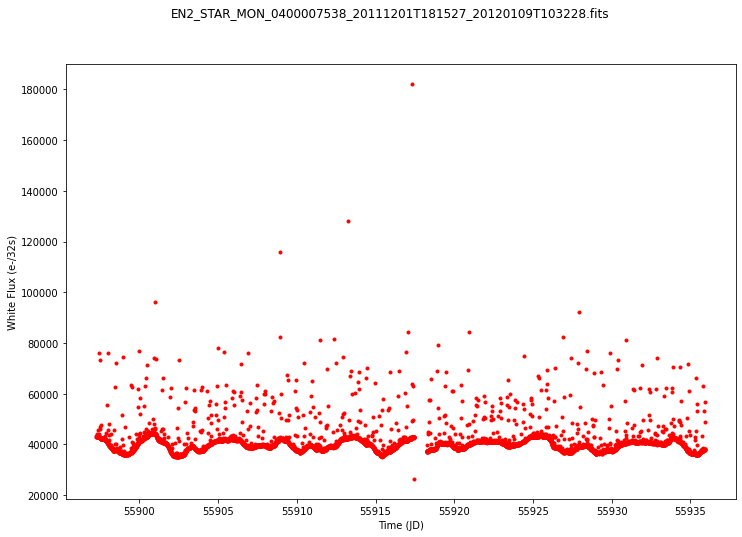

In [8]:
# Plot the LC
fig, ax = plt.subplots()
fig.set_size_inches(12., 8.)
ax.plot(jds, white_flux, 'r.')

fig.suptitle(file)
ax.set_ylabel("White Flux (e-/32s)")
ax.set_xlabel("Time (JD)")

#plt.savefig('Lightcurve.png')

In [9]:
white_flux.shape

(6394,)

In [10]:
median = np.median(white_flux)
median

40138.24

In [11]:
mean = np.mean(white_flux)
mean

40811.582

Text(0.5, 0, 'Time (JD)')

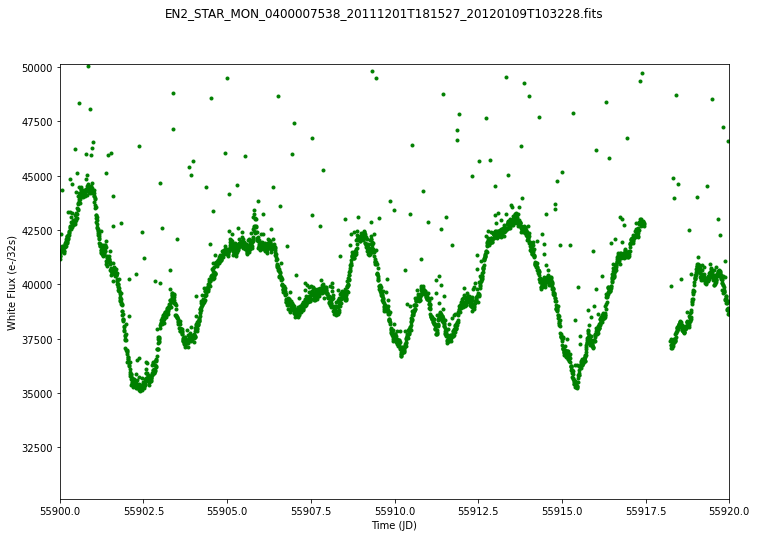

In [12]:
fig, ax = plt.subplots()
fig.set_size_inches(12., 8.)
ax.plot(jds, white_flux, 'g.')

ax.set_xlim(55900, 55920)
ax.set_ylim((median-10000), (median + 10000))

fig.suptitle(file)
ax.set_ylabel("White Flux (e-/32s)")
ax.set_xlabel("Time (JD)")